In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
data = pd.read_csv(r'E:\Dataset\titanic.csv')
print(data.head())

numeric_features = ['Pclass','Age','SibSp','Parch','Fare']
data=data.dropna(subset=numeric_features + ['Survived'])

X = data[numeric_features]
y = data['Survived']

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
poly_svm = SVC(kernel="poly", degree=3, C=1)
poly_svm.fit(X_train, y_train)
y_pred_poly = poly_svm.predict(X_test)
print("Polynomial Kernel Accuracy:", accuracy_score(y_test, y_pred_poly))

Polynomial Kernel Accuracy: 0.6993006993006993


In [6]:
rbf_svm = SVC(kernel="rbf", gamma="scale", C=1)
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)
print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

RBF Kernel Accuracy: 0.6783216783216783


In [7]:
sigmoid_svm = SVC(kernel="sigmoid", C=1)
sigmoid_svm.fit(X_train, y_train)
y_pred_sigmoid = sigmoid_svm.predict(X_test)
print("Sigmoid Kernel Accuracy:", accuracy_score(y_test, y_pred_sigmoid))

Sigmoid Kernel Accuracy: 0.6293706293706294


In [8]:
print("\n--- Kernel Comparison ---")
print("Polynomial Accuracy:", accuracy_score(y_test, y_pred_poly))
print("RBF Accuracy       :", accuracy_score(y_test, y_pred_rbf))
print("Sigmoid Accuracy   :", accuracy_score(y_test, y_pred_sigmoid))


--- Kernel Comparison ---
Polynomial Accuracy: 0.6993006993006993
RBF Accuracy       : 0.6783216783216783
Sigmoid Accuracy   : 0.6293706293706294


In [9]:
print("\nClassification Report: (RBF Kernel)\n")
print(classification_report(y_test, y_pred_rbf))


Classification Report: (RBF Kernel)

              precision    recall  f1-score   support

           0       0.69      0.86      0.77        87
           1       0.65      0.39      0.49        56

    accuracy                           0.68       143
   macro avg       0.67      0.63      0.63       143
weighted avg       0.67      0.68      0.66       143



In [10]:
cm = confusion_matrix(y_test, y_pred_rbf)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[75 12]
 [34 22]]


In [11]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

In [12]:
def classification_plot(model, X_train, y_train, X_test, y_test, title):
 x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
 y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
 xx, yy = np.meshgrid(
 np.linspace(x_min, x_max, 300),
 np.linspace(y_min, y_max, 300)
 )
 # Predict class for each region
 Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
 Z = Z.reshape(xx.shape)
 # Plot decision regions
 plt.figure()
 plt.contourf(xx, yy, Z, alpha=0.25)
 # Training points
 plt.scatter(X_train[:, 0], X_train[:, 1],
 c=y_train, marker="o", label="Train Data")
 # Testing points
 plt.scatter(X_test[:, 0], X_test[:, 1],
 c=y_test, marker="x", label="Test Data")
 plt.title(title)
 plt.xlabel("PCA Component 1")
 plt.ylabel("PCA Component 2")
 plt.legend()
 plt.show()

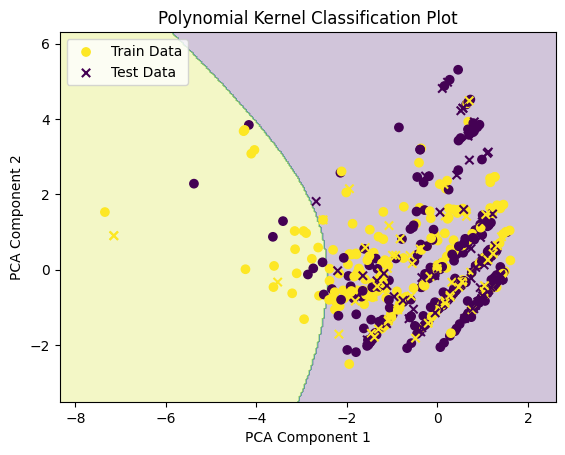

In [13]:
poly_svm = SVC(kernel="poly", degree=3, C=1)
poly_svm.fit(X_train_2d, y_train)
classification_plot(poly_svm, X_train_2d, y_train, X_test_2d, y_test, "Polynomial Kernel Classification Plot")

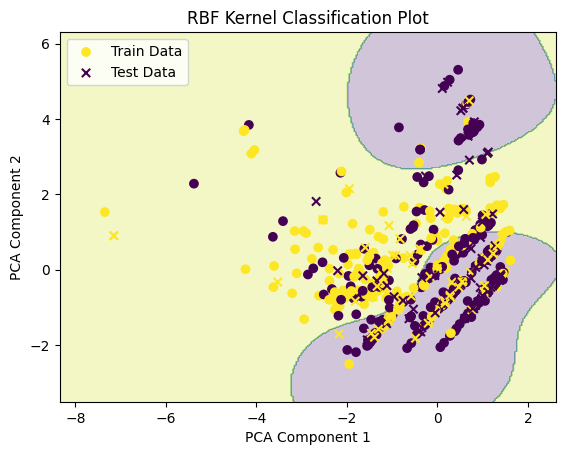

In [14]:
rbf_svm = SVC(kernel="rbf", gamma="scale", C=1)
rbf_svm.fit(X_train_2d, y_train)
classification_plot(rbf_svm, X_train_2d, y_train, X_test_2d, y_test, "RBF Kernel Classification Plot")

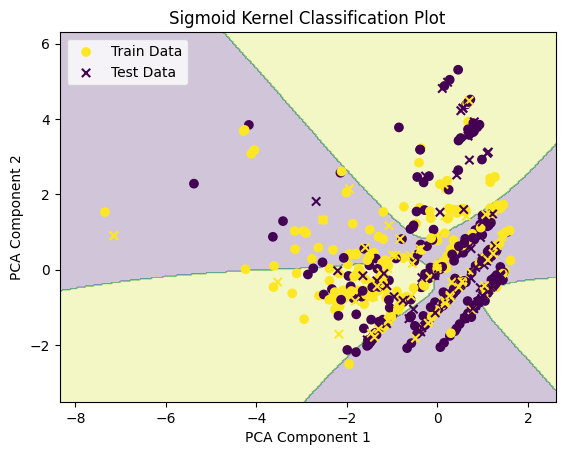

In [15]:
sigmoid_svm = SVC(kernel="sigmoid", C=1)
sigmoid_svm.fit(X_train_2d, y_train)
classification_plot(sigmoid_svm, X_train_2d, y_train, X_test_2d, y_test, "Sigmoid Kernel Classification Plot")